# Example 3: Sub-Hourly Streamflow Forecasting (Experiment 3)

Mirrors the paper's Experiment 3: forecasting at a native temporal resolution (15 minutes) and in a
geographic domain (Luxembourg, CAMELS-LUX) absent from pretraining -- testing HydroORBIT's
resolution-agnostic design.

**Case study**: CAMELS-LUX basin `40` -- selected as the highest-median-NSE basin with full
lead-time coverage in the paper's Experiment 2 (CAMELS-LUX) evaluation. This notebook runs 30
forecast cycles spread across the 2021 evaluation year (the CAMELS-LUX record ends 2021-11-01) and
reports NSE **at each lead time**, pooled across those 30 cycles.

Data: `data/exp3_subhourly_lux/LUX_40.csv` -- native 15-minute discharge (`Q`, m3/s) and covariates,
2020-01-01 to 2021-11-01; 2020 provides trailing context for origins issued during 2021.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from src.pipeline import HydroORBITPipeline

WEIGHTS_DIR = REPO_ROOT / "weights"
pipe = HydroORBITPipeline.from_pretrained(str(WEIGHTS_DIR))
print("Loaded HydroORBIT on device:", pipe.device)

FORCING_COLS = ["Tair", "Qair", "PSurf", "Wind_E", "Wind_N", "LWdown",
                "CRainf_frac", "CAPE", "PotEvap", "Rainf", "SWdown"]

def nse(obs, sim, min_samples=24):
    """Nash-Sutcliffe efficiency, pooled across whatever (obs, sim) pairs are given.
    Returns NaN below min_samples or when the observed variance is degenerate
    (near-constant obs), matching the guard used for the paper's own metrics."""
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    mask = np.isfinite(obs) & np.isfinite(sim)
    obs, sim = obs[mask], sim[mask]
    if len(obs) < min_samples:
        return np.nan
    den = np.sum((obs - obs.mean()) ** 2)
    scale = max(abs(obs.mean()), 1.0)
    if den <= (1e-10 * scale) ** 2 * len(obs):
        return np.nan
    return 1.0 - np.sum((sim - obs) ** 2) / den


def origins_for_eval_year(index, year, context_len, horizon):
    """Positions in `index` that fall within `year` and have enough trailing
    context (context_len) and enough remaining data (horizon) around them."""
    positions = np.where(index.year == year)[0]
    positions = positions[(positions >= context_len) & (positions + horizon <= len(index))]
    return positions


Loaded HydroORBIT on device: mps


In [2]:
BASIN = "LUX_40"
CONTEXT_LEN = 8760       # ~91 days of 15-min steps
HORIZON = 96                # 24 hours at 15-min resolution, the paper's longest sub-hourly lead time
N_ORIGINS = 30                # forecast cycles spread across the 2021 evaluation year
EVAL_YEAR = 2021

df = pd.read_csv(f"data/exp3_subhourly_lux/{BASIN}.csv", index_col="datetime", parse_dates=True)
print(df.shape, df.index.min(), "->", df.index.max())
df.tail()


(64321, 3) 2020-01-01 00:00:00 -> 2021-11-01 00:00:00


,Q,Precip,AirTemp
datetime,,,
2021-10-31 23:00:00,3.936,0.0,9.13
2021-10-31 23:15:00,3.936,0.0,8.33
2021-10-31 23:30:00,3.936,0.0,8.33
2021-10-31 23:45:00,3.947,0.0,8.33
2021-11-01 00:00:00,3.936,0.0,8.33


In [3]:
COV_COLS = ["Precip", "AirTemp"]
positions = origins_for_eval_year(df.index, EVAL_YEAR, CONTEXT_LEN, HORIZON)
origins = positions[np.linspace(0, len(positions) - 1, N_ORIGINS).astype(int)]

runs = []
for origin in origins:
    ctx_slice = df.iloc[origin - CONTEXT_LEN:origin]
    fut_slice = df.iloc[origin:origin + HORIZON]
    target = ctx_slice["Q"].to_numpy(np.float32)
    forcing = ctx_slice[COV_COLS].to_numpy(np.float32)
    future_forcing = fut_slice[COV_COLS].to_numpy(np.float32)
    observed_future = fut_slice["Q"].to_numpy(np.float32)

    out = pipe.predict(target, forcing=forcing, future_forcing=future_forcing, prediction_length=HORIZON)
    median = out.median[0].numpy()
    runs.append({"issue_time": df.index[origin], "observed": observed_future, "median": median})
print(f"Ran {len(runs)} forecast cycles across {EVAL_YEAR}.")


Ran 30 forecast cycles across 2021.


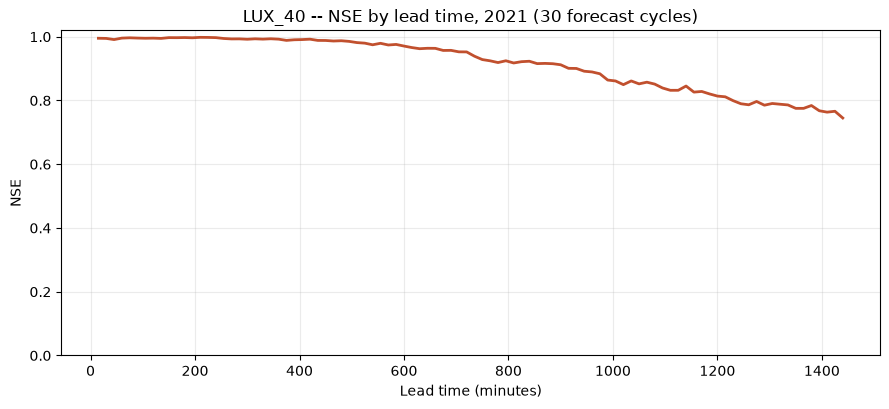

Median NSE across all leads: 0.946  (lead 15min: 0.995, lead 24h: 0.745)


In [4]:
obs_stack = np.stack([r["observed"] for r in runs])
sim_stack = np.stack([r["median"] for r in runs])
lead_min = np.arange(1, HORIZON + 1) * 15
nse_by_lead = np.array([nse(obs_stack[:, h], sim_stack[:, h]) for h in range(HORIZON)])

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(lead_min, nse_by_lead, color="#C1502E", linewidth=2.0)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Lead time (minutes)")
ax.set_ylabel("NSE")
ax.set_title(f"{BASIN} -- NSE by lead time, {EVAL_YEAR} ({N_ORIGINS} forecast cycles)")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
print(f"Median NSE across all leads: {np.nanmedian(nse_by_lead):.3f}  "
      f"(lead 15min: {nse_by_lead[0]:.3f}, lead 24h: {nse_by_lead[-1]:.3f})")
